<a href="https://colab.research.google.com/github/Optimus0205/Data_Science_Project/blob/main/Analytics_Module_(visualization).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df=pd.read_csv('/content/gurgaon_properties_missing_value_imputation.csv')
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,eldeco accolade,sohna road,0.87,5963.0,2,2,3+,10.0,Relatively New,1131.0,1,0,0,0,0,0,72
1,flat,tulip violet,sector 69,2.00,9583.0,4,4,2,0.0,Relatively New,1889.0,0,0,0,0,0,0,157
2,flat,unitech uniworld gardens,sector 47,2.40,11505.0,3,3,3+,10.0,Moderately Old,1888.0,0,1,0,0,0,1,120
3,flat,emaar palm gardens,sector 83,1.75,9211.0,3,3,3,6.0,Relatively New,1600.0,0,1,0,0,0,1,174
4,flat,vatika iris floors,sector 82,0.63,5590.0,2,2,3+,2.0,Relatively New,1026.0,1,0,0,0,0,0,110


In [3]:
df.shape

(3268, 18)

# 1. Geographic Map

In [4]:
latlong=pd.read_csv('latlong.csv')
latlong.head()

,sector,coordinates
0,sector 1,"28.3663° N, 76.9456° E"
1,sector 2,"28.5095° N, 77.0320° E"
2,sector 3,"28.4909° N, 77.0176° E"
3,sector 4,"28.4738° N, 77.0107° E"
4,sector 5,"28.4794° N, 77.0176° E"


In [5]:
latlong['latitude'] = latlong['coordinates'].str.split(',').str.get(0).str.split('°').str.get(0).astype('float')

In [6]:
latlong['longitude'] = latlong['coordinates'].str.split(',').str.get(1).str.split('°').str.get(0).astype('float')

In [7]:
latlong

,sector,coordinates,latitude,longitude
0,sector 1,"28.3663° N, 76.9456° E",28.3663,76.9456
1,sector 2,"28.5095° N, 77.0320° E",28.5095,77.0320
2,sector 3,"28.4909° N, 77.0176° E",28.4909,77.0176
3,sector 4,"28.4738° N, 77.0107° E",28.4738,77.0107
4,sector 5,"28.4794° N, 77.0176° E",28.4794,77.0176
...,...,...,...,...
124,sector 113,"28.5287° N, 77.0233° E",28.5287,77.0233
125,sector 114,"28.5334° N, 77.0118° E",28.5334,77.0118
126,sector 115,"28.5385° N, 77.0061° E",28.5385,77.0061
127,gwal pahari,"28.4484° N, 77.0210° E",28.4484,77.0210


In [8]:
new_df = df.merge(latlong, on='sector')

In [9]:
new_df

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,...,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,coordinates,latitude,longitude
0,flat,tulip violet,sector 69,2.00,9583.0,4,4,2,0.0,Relatively New,...,0,0,0,0,0,0,157,"28.3966° N, 77.0341° E",28.3966,77.0341
1,flat,unitech uniworld gardens,sector 47,2.40,11505.0,3,3,3+,10.0,Moderately Old,...,0,1,0,0,0,1,120,"28.4276° N, 77.0492° E",28.4276,77.0492
2,flat,emaar palm gardens,sector 83,1.75,9211.0,3,3,3,6.0,Relatively New,...,0,1,0,0,0,1,174,"28.3986° N, 76.9647° E",28.3986,76.9647
3,flat,vatika iris floors,sector 82,0.63,5590.0,2,2,3+,2.0,Relatively New,...,1,0,0,0,0,0,110,"28.3935° N, 76.9600° E",28.3935,76.9600
4,house,independent,sector 105,1.20,13333.0,4,4,1,2.0,Moderately Old,...,0,0,0,0,1,0,14,"28.4952° N, 77.0114° E",28.4952,77.0114
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3044,flat,puri emerald bay,sector 104,2.23,9911.0,3,4,3+,10.0,Relatively New,...,0,1,0,0,0,1,159,"28.4788° N, 76.9960° E",28.4788,76.9960
3045,flat,signature andour heights,sector 71,0.59,8429.0,2,2,1,6.0,Moderately Old,...,0,0,0,0,0,0,67,"28.4104° N, 77.0281° E",28.4104,77.0281
3046,flat,adani m2k oyster grande,sector 102,2.61,10046.0,3,3,3,14.0,Relatively New,...,1,1,0,0,0,0,21,"28.4750° N, 76.9715° E",28.4750,76.9715
3047,flat,bestech park view sanskruti,sector 92,1.55,7769.0,3,4,3,8.0,Relatively New,...,0,1,0,0,0,0,49,"28.4079° N, 76.9153° E",28.4079,76.9153


In [10]:
for col in ['price','price_per_sqft','built_up_area','latitude','longitude']:
    new_df[col] = pd.to_numeric(new_df[col].astype(str), errors='coerce')

# Select only the 'sector' and the intended numeric columns for groupby
numeric_cols = ['price','price_per_sqft','built_up_area','latitude','longitude']
group_df = new_df[['sector'] + numeric_cols].groupby('sector').mean()

In [11]:
group_df

,price,price_per_sqft,built_up_area,latitude,longitude
sector,,,,,
gwal pahari,3.668000,10194.066667,3437.866667,28.4484,77.0210
manesar,0.921481,4490.370370,1985.903704,28.3515,76.9428
sector 1,1.860000,8249.833333,2327.833333,28.3663,76.9456
sector 102,1.687524,10565.380952,1547.619048,28.4750,76.9715
sector 103,1.527500,7485.805556,1893.472222,28.4949,76.9845
...,...,...,...,...,...
sector 92,1.041519,6674.962025,1548.987342,28.4079,76.9153
sector 93,0.848889,8009.888889,1017.000000,28.4153,76.9326
sector 95,0.461000,5452.975000,1000.775000,28.4172,76.9081


In [12]:
fig = px.scatter_mapbox(group_df, lat="latitude", lon="longitude", color="price_per_sqft", size='built_up_area',
                  color_continuous_scale=px.colors.cyclical.IceFire, zoom=10,
                  mapbox_style="open-street-map",text=group_df.index)
fig.show()

In [13]:
new_df.to_csv('data_viz1.csv',index=False)

#2. WorldCloud Ammenities

In [14]:
df1 = pd.read_csv('gurgaon_properties.csv')
df1.head()

,property_name,property_type,society,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,address,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating
0,2 BHK Flat in Sohna,flat,eldeco accolade,0.87,5965.0,1459.0,Super Built up area 1457(135.36 sq.m.)Carpet a...,2,2,3+,study room,"Sohna, Gurgaon, Haryana",10.0,NaN,1 to 5 Year Old,"['Global City Centre', 'Sohna Road', 'Damdama ...",Residential apartment for sell.The property ha...,[],"['Power Back-up', 'Feng Shui / Vaastu Complian...","['Green Area5 out of 5', 'Construction4.5 out ..."
1,4 BHK Flat in Sector 69 Gurgaon,flat,tulip violet,2.00,9583.0,2087.0,Super Built up area 2087(193.89 sq.m.),4,4,2,not available,"002, Sector 69 Gurgaon, Gurgaon, Haryana",0.0,South-East,1 to 5 Year Old,"['Airia Mall Sector 68', 'Southern Peripheral ...",Ground floor with extended balcony this 4 bhk ...,"['1 Modular Kitchen', 'No AC', 'No Bed', 'No C...","['Water purifier', 'Security / Fire Alarm', 'P...","['Green Area5 out of 5', 'Construction4 out of..."
2,3 BHK Flat in Sector 47 Gurgaon,flat,unitech uniworld gardens,2.40,11505.0,2086.0,Super Built up area 2086(193.8 sq.m.),3,3,3+,servant room,"Sector 47 Gurgaon, Gurgaon, Haryana",10.0,NaN,5 to 10 Year Old,"['Rajiv Chowk Mosque', 'Standard chartered ATM...","3bhk + sq, 2086 sq feet\nSemi-Furnished \nNewl...","['3 Wardrobe', '6 Fan', '3 Geyser', '15 Light'...","['Security / Fire Alarm', 'Feng Shui / Vaastu ...","['Green Area4 out of 5', 'Construction4 out of..."
3,3 BHK Flat in Sector 83 Gurgaon,flat,emaar palm gardens,1.75,9210.0,1900.0,Super Built up area 1900(176.52 sq.m.)Built Up...,3,3,3,servant room,"403, Sector 83 Gurgaon, Gurgaon, Haryana",6.0,East,1 to 5 Year Old,"[""V'Lante Mall"", 'NH 48 Gurugram', 'iGrow Mont...",This 3 bhk flat is located in emaar palm garde...,"['3 Wardrobe', '8 Fan', '1 Exhaust Fan', '1 Di...","['Water purifier', 'Centrally Air Conditioned'...","['Green Area5 out of 5', 'Construction4 out of..."
4,2 BHK Flat in Sector 82 Gurgaon,flat,vatika iris floors,0.63,5590.0,1127.0,Super Built up area 1134(105.35 sq.m.),2,2,3+,study room,"Sector 82 Gurgaon, Gurgaon, Haryana",2.0,East,1 to 5 Year Old,"['Vatika Town Square-INXT', 'NH 48, Sector 78,...",This property is very good becouse of itsattre...,NaN,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...","['Environment4 out of 5', 'Lifestyle4 out of 5..."


In [15]:
wordcloud_df = df1.merge(df, left_index=True, right_index=True)[['features','sector']]
wordcloud_df.head()

,features,sector
0,"['Power Back-up', 'Feng Shui / Vaastu Complian...",sohna road
1,"['Water purifier', 'Security / Fire Alarm', 'P...",sector 69
2,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",sector 47
3,"['Water purifier', 'Centrally Air Conditioned'...",sector 83
4,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",sector 82


In [16]:
import ast
main = []
for item in wordcloud_df['features'].dropna().apply(ast.literal_eval):
    main.extend(item)

In [17]:
main

['Power Back-up',
 'Feng Shui / Vaastu Compliant',
 'Intercom Facility',
 'Lift(s)',
 'Maintenance Staff',
 'Swimming Pool',
 'Park',
 'Security Personnel',
 'Internet/wi-fi connectivity',
 'Shopping Centre',
 'Fitness Centre / GYM',
 'Rain Water Harvesting',
 'Club house / Community Center',
 'Water purifier',
 'Security / Fire Alarm',
 'Power Back-up',
 'Feng Shui / Vaastu Compliant',
 'Private Garden / Terrace',
 'Intercom Facility',
 'Lift(s)',
 'High Ceiling Height',
 'Maintenance Staff',
 'False Ceiling Lighting',
 'Water Storage',
 'No open drainage around',
 'Bank Attached Property',
 'Piped-gas',
 'Internet/wi-fi connectivity',
 'Recently Renovated',
 'Visitor Parking',
 'Swimming Pool',
 'Park',
 'Security Personnel',
 'Natural Light',
 'Airy Rooms',
 'Spacious Interiors',
 'Low Density Society',
 'Waste Disposal',
 'Rain Water Harvesting',
 'Water softening plant',
 'Shopping Centre',
 'Fitness Centre / GYM',
 'Club house / Community Center',
 'Security / Fire Alarm',
 'Feng

In [18]:
from wordcloud import WordCloud

In [19]:
feature_text = ' '.join(main)

In [20]:
import pickle
pickle.dump(feature_text, open('feature_text.pkl','wb'))

In [21]:
feature_text

'Power Back-up Feng Shui / Vaastu Compliant Intercom Facility Lift(s) Maintenance Staff Swimming Pool Park Security Personnel Internet/wi-fi connectivity Shopping Centre Fitness Centre / GYM Rain Water Harvesting Club house / Community Center Water purifier Security / Fire Alarm Power Back-up Feng Shui / Vaastu Compliant Private Garden / Terrace Intercom Facility Lift(s) High Ceiling Height Maintenance Staff False Ceiling Lighting Water Storage No open drainage around Bank Attached Property Piped-gas Internet/wi-fi connectivity Recently Renovated Visitor Parking Swimming Pool Park Security Personnel Natural Light Airy Rooms Spacious Interiors Low Density Society Waste Disposal Rain Water Harvesting Water softening plant Shopping Centre Fitness Centre / GYM Club house / Community Center Security / Fire Alarm Feng Shui / Vaastu Compliant Intercom Facility Lift(s) Maintenance Staff Water Storage No open drainage around Recently Renovated Piped-gas Visitor Parking Swimming Pool Park Securi

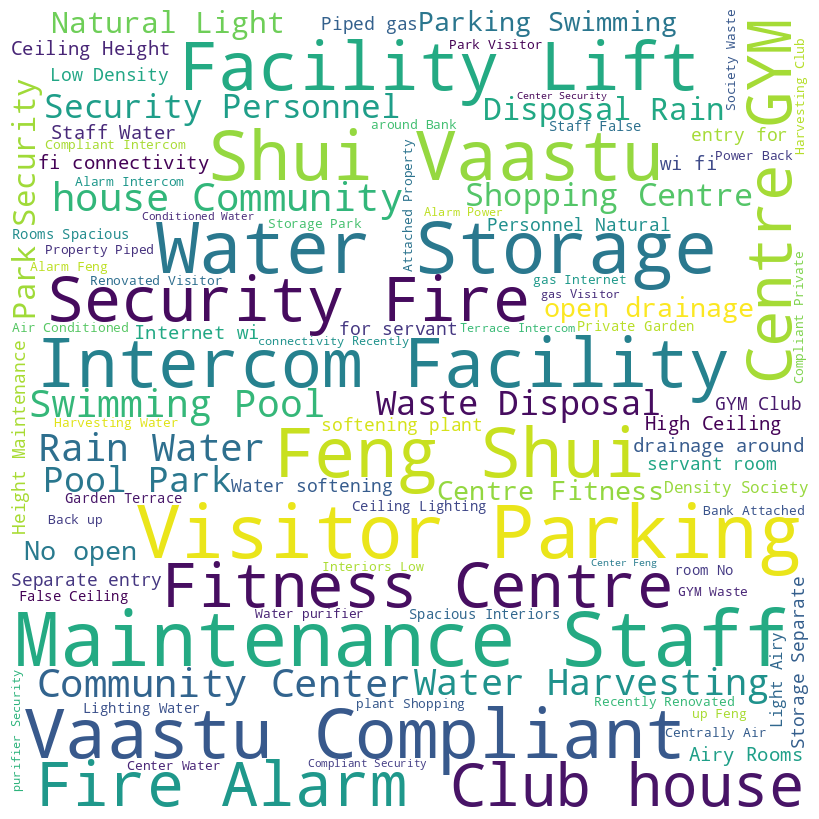

In [22]:
plt.rcParams["font.family"] = "Arial"

wordcloud = WordCloud(width = 800, height = 800,
                      background_color ='white',
                      stopwords = set(['s']),  # Any stopwords you'd like to exclude
                      min_font_size = 10).generate(feature_text)

plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.tight_layout(pad = 0)
plt.show() # st.pyplot()

## 3. Scatterplot ->  area vs price

In [23]:
fig = px.scatter(df, x="built_up_area", y="price", color="bedRoom", title="Area Vs Price")

# Show the plot
fig.show()

## 4. Pie Chart ->  bedroom vs sector

In [24]:
fig = px.pie(df, names='bedRoom', title='Total Bill Amount by Day')

# Show the plot
fig.show()

## 5. Boxplot  Bedroom vs price

In [25]:
temp_df = df[df['bedRoom'] <= 4]
# Create side-by-side boxplots of the total bill amounts by day
fig = px.box(temp_df, x='bedRoom', y='price', title='BHK Price Range')

# Show the plot
fig.show()

## 6. Distplot Price vs Flat/House

/tmp/ipykernel_544/3761596323.py:1: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751


/tmp/ipykernel_544/3761596323.py:2: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




<Axes: xlabel='price', ylabel='Density'>

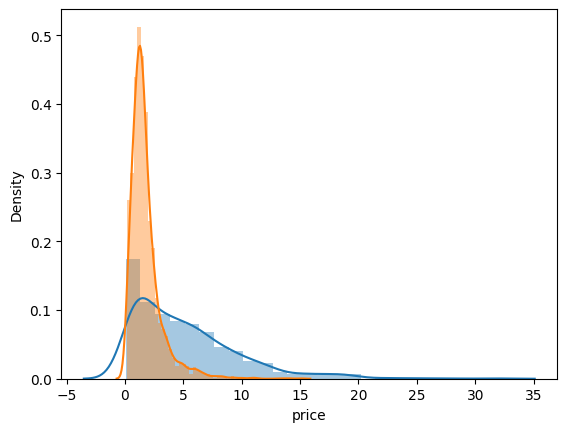

In [26]:
sns.distplot(df[df['property_type'] == 'house']['price'])
sns.distplot(df[df['property_type'] == 'flat']['price'])